# Simulation-Style Score-Compressed Student-t Likelihood

This notebook validates a workflow that looks like a real simulation pipeline:

1. define an observed statistic vector;
2. run mock simulations at the fiducial point to estimate the statistic covariance;
3. run finite-difference simulations to estimate the local response of the statistic to parameters;
4. build score-compressed summaries from those simulation products only;
5. run the Sellentin-Heavens/Student-t compressed likelihood;
6. compare to the analytical HMC benchmark only as a validation diagnostic.

The analytical theory is used only inside a black-box simulator that emits noisy mock statistics. The inference code below does not use the saved theory covariance or analytical summaries directly. Later, the only interface to replace should be `get_observed_statistic()` and `simulate_statistic(theta, seed)`.

## Imports and Configuration

The cell starts with `%matplotlib inline` because GetDist plotters otherwise may not render in this notebook environment.

In [1]:
%matplotlib inline

from __future__ import annotations

import hashlib
import json
import os
import pathlib
import sys
import time
from dataclasses import dataclass
from typing import Any, Callable

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "")
os.environ.setdefault("JAX_PLATFORMS", "cpu")
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")

import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
except Exception:
    pd = None

from getdist import MCSamples, plots, chains
from matplotlib.colors import to_hex

chains.print_load_details = False

from jax import config as jax_config
jax_config.update("jax_enable_x64", True)
import jax.numpy as jnp

CWD = pathlib.Path.cwd().resolve()
if (CWD / "notebooks" / "SBI_validate").exists():
    REPO_ROOT = CWD
    SBI_DIR = CWD / "notebooks" / "SBI_validate"
elif CWD.name == "SBI_validate":
    SBI_DIR = CWD
    REPO_ROOT = CWD.parents[1]
else:
    for parent in (CWD, *CWD.parents):
        candidate = parent / "notebooks" / "SBI_validate"
        if candidate.exists():
            REPO_ROOT = parent
            SBI_DIR = candidate
            break
    else:
        raise RuntimeError("Could not locate notebooks/SBI_validate")

if str(SBI_DIR) not in sys.path:
    sys.path.insert(0, str(SBI_DIR))

from theory_sbi_utils import (
    DEFAULT_FIDUCIAL_PATH,
    THEORY_SBI_DIR,
    default_parameter_specs,
    fiducial_theta,
    make_inference_theory_vector_function,
    prior_bounds,
    selected_product_arrays,
)

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 160,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "legend.frameon": False,
})

FIDUCIAL_PATH = pathlib.Path(DEFAULT_FIDUCIAL_PATH).resolve()
HMC_DIR = pathlib.Path(THEORY_SBI_DIR) / "joint_gg_gy_gtau_gkappa_linearized_hmc_strict"
OUTPUT_DIR = pathlib.Path(THEORY_SBI_DIR) / "simulation_style_student_t_compressed_likelihood"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

PROBES = ("gg", "gy", "gtau", "gkappa")
ELL_MIN = None
ELL_MAX = None
THEORY_BACKEND_FOR_HIDDEN_SIMULATOR = "linearized"

PARAM_SPECS = default_parameter_specs()
PARAM_NAMES = tuple(spec.name for spec in PARAM_SPECS)
PARAM_LABELS = tuple(spec.label for spec in PARAM_SPECS)
THETA0 = fiducial_theta(PARAM_SPECS)
PRIOR_MIN, PRIOR_MAX = prior_bounds(PARAM_SPECS)
NPARAM = len(THETA0)

# Low enough to run quickly, high enough to invert an 80-dimensional raw covariance.
COVARIANCE_BUDGETS = (96, 128, 256, 512)
N_FD_PAIRS = 64
FD_DELTAS = 0.05 * (PRIOR_MAX - PRIOR_MIN)
FD_DELTAS[FD_DELTAS == 0] = 1.0e-3
USE_COMMON_RANDOM_NUMBERS_FOR_FD = True
RAW_COV_SHRINKAGE = 0.0
RAW_COV_EIGEN_FLOOR_FRAC = 1.0e-18
GRID_SIZE = 420
POSTERIOR_SAMPLES = 50_000
BASE_SEED = 20260527

GETDIST_SETTINGS = {
    "ignore_rows": 0,
    "smooth_scale_1D": 0.35,
    "smooth_scale_2D": 0.45,
    "boundary_correction_order": 1,
}


def display_table(rows: list[dict[str, Any]], columns: list[str] | None = None):
    if pd is not None:
        frame = pd.DataFrame(rows)
        if columns is not None and len(frame):
            frame = frame[[c for c in columns if c in frame.columns]]
        display(frame)
    else:
        print(json.dumps(rows, indent=2, default=str))

print(f"Repository root: {REPO_ROOT}")
print(f"Fiducial product: {FIDUCIAL_PATH}")
print(f"HMC benchmark directory: {HMC_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"Parameters: {PARAM_NAMES}")

Repository root: /mnt/ceph/users/spandey/ltu-godmax/GODMAX
Fiducial product: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/SBI_validate/outputs/theory_sbi/fiducial_thetaej2_nuejm_minus0p1.npz
HMC benchmark directory: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/SBI_validate/outputs/theory_sbi/joint_gg_gy_gtau_gkappa_linearized_hmc_strict
Output directory: /mnt/ceph/users/spandey/ltu-godmax/GODMAX/notebooks/SBI_validate/outputs/theory_sbi/simulation_style_student_t_compressed_likelihood
Parameters: ('theta_ej_0', 'nu_theta_ej_M')


## Hidden Analytical Simulator

This block constructs the analytical analog of a map simulation. In a real run, `simulate_statistic(theta, seed)` would create maps/catalogs, add survey noise, and measure whatever statistics you want. Here it returns a noisy analytical $C_\ell$ statistic vector with the same shape as the fiducial theory data vector.

The downstream calibration and likelihood cells do **not** inspect the hidden covariance or analytical Jacobian. They only call the simulator and consume arrays.

In [2]:
selected = selected_product_arrays(FIDUCIAL_PATH, probes=PROBES, ell_min=ELL_MIN, ell_max=ELL_MAX)
selection = selected["selection"]
OBSERVED_STATISTIC = np.asarray(selected["data_vector"], dtype=float)
TRUE_COV_HIDDEN = np.asarray(selected["cov"], dtype=float)
TRUE_CHOL_HIDDEN = np.asarray(selected["chol"], dtype=float)
STATISTIC_LABELS = tuple(selection.labels)
NDATA = len(OBSERVED_STATISTIC)

hidden_vector_fn, hidden_theory_info = make_inference_theory_vector_function(
    PARAM_SPECS,
    selection,
    fiducial_vector=OBSERVED_STATISTIC,
    backend=THEORY_BACKEND_FOR_HIDDEN_SIMULATOR,
    fiducial_offset=True,
    jit_compile=True,
)
TRUE_JACOBIAN_HIDDEN = np.asarray(hidden_theory_info["jacobian"], dtype=float)


def hidden_mean_statistic(theta: np.ndarray) -> np.ndarray:
    """Hidden mean model used only by the analytical mock simulator."""
    theta = np.asarray(theta, dtype=float)
    return np.asarray(hidden_vector_fn(jnp.asarray(theta, dtype=jnp.float64)), dtype=float)


class AnalyticalStatisticSimulator:
    """Analytical stand-in for map/catalog simulations plus measurement."""

    def __init__(self, mean_fn: Callable[[np.ndarray], np.ndarray], chol: np.ndarray):
        self.mean_fn = mean_fn
        self.chol = np.asarray(chol, dtype=float)
        self.ndata = self.chol.shape[0]

    def simulate(self, theta: np.ndarray, seed: int, *, add_noise: bool = True) -> np.ndarray:
        theta = np.asarray(theta, dtype=float)
        mean = self.mean_fn(theta)
        if not add_noise:
            return mean
        rng = np.random.default_rng(int(seed))
        return mean + self.chol @ rng.normal(size=self.ndata)


_SIMULATOR = AnalyticalStatisticSimulator(hidden_mean_statistic, TRUE_CHOL_HIDDEN)


def get_observed_statistic() -> np.ndarray:
    """Replace this later with measured statistics from the observed maps/catalog."""
    return OBSERVED_STATISTIC.copy()


def simulate_statistic(theta: np.ndarray, seed: int) -> np.ndarray:
    """Replace this later with a real simulation plus measurement call."""
    return _SIMULATOR.simulate(theta, seed=seed, add_noise=True)


def simulate_statistic_batch(theta: np.ndarray, seeds: np.ndarray) -> np.ndarray:
    return np.vstack([simulate_statistic(theta, int(seed)) for seed in np.asarray(seeds, dtype=np.int64)])

obs_stat = get_observed_statistic()
summary_rows = [
    {"quantity": "statistic dimension", "value": NDATA},
    {"quantity": "selected probes", "value": ", ".join(PROBES)},
    {"quantity": "fiducial theta", "value": THETA0.tolist()},
    {"quantity": "prior min", "value": PRIOR_MIN.tolist()},
    {"quantity": "prior max", "value": PRIOR_MAX.tolist()},
    {"quantity": "covariance budgets", "value": list(COVARIANCE_BUDGETS)},
    {"quantity": "finite-difference pairs per parameter", "value": N_FD_PAIRS},
    {"quantity": "raw covariance shrinkage", "value": RAW_COV_SHRINKAGE},
    {"quantity": "raw covariance eigen floor fraction", "value": f"{RAW_COV_EIGEN_FLOOR_FRAC:.1e}"},
]
display_table(summary_rows)

[nz consistency] max fractional mismatch = 0.0000e+00, mean = 0.0000e+00  (rtol=0.05)


,quantity,value
0,statistic dimension,80
1,selected probes,"gg, gy, gtau, gkappa"
2,fiducial theta,"[2.0, -0.1]"
3,prior min,"[0.5, -1.0]"
4,prior max,"[4.0, 0.0]"
5,covariance budgets,"[96, 128, 256, 512]"
6,finite-difference pairs per parameter,64
7,raw covariance shrinkage,0.0
8,raw covariance eigen floor fraction,1.0e-18


## Observed Statistic

For this validation, the observed statistic is the same fiducial analytical data vector used by the HMC benchmark. Later this can be any vector: binned $C_\ell$s, moments, peak counts, or a concatenation of several statistics.

In [3]:
product = np.load(FIDUCIAL_PATH, allow_pickle=True)
ell = np.asarray(product["ell"], dtype=float)
spectra_order = tuple(str(x) for x in product["spectra_order"])
nell = len(ell)

fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.2), sharex=True)
axes = axes.ravel()
colors = {"gg": "#3b5b92", "gy": "#b35c1e", "gtau": "#2f7d5f", "gkappa": "#7a4fa3"}
for ax, probe in zip(axes, PROBES):
    block = spectra_order.index(probe)
    full_idx = block * nell + selection.ell_indices
    local_idx = np.arange(PROBES.index(probe) * len(selection.ell_indices), (PROBES.index(probe) + 1) * len(selection.ell_indices))
    y = obs_stat[local_idx]
    ax.plot(ell[selection.ell_indices], y, marker="o", ms=3.2, lw=1.4, color=colors[probe])
    ax.set_title(probe)
    ax.set_xscale("log")
    if np.all(y > 0):
        ax.set_yscale("log")
    else:
        ax.set_yscale("symlog", linthresh=max(np.nanmedian(np.abs(y))*1e-2, 1e-20))
for ax in axes[-2:]:
    ax.set_xlabel(r"$\ell$")
for ax in axes[::2]:
    ax.set_ylabel("observed statistic")
fig.suptitle("Observed validation statistic: analytical 2pt data vector", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()
plt.close(fig)

## Simulation Calibration Code

Everything below this point uses the replaceable simulation interface. The hidden theory covariance and hidden analytical Jacobian are used only in the final diagnostic table to check whether the simulation-style estimates are behaving sensibly.

In [4]:
def stable_covariance(samples: np.ndarray) -> np.ndarray:
    samples = np.asarray(samples, dtype=float)
    return np.cov(samples.T, ddof=1)


def shrink_covariance(cov: np.ndarray, shrinkage: float = 0.05) -> np.ndarray:
    cov = 0.5 * (np.asarray(cov, dtype=float) + np.asarray(cov, dtype=float).T)
    diag = np.diag(np.diag(cov))
    shrunk = (1.0 - shrinkage) * cov + shrinkage * diag
    return 0.5 * (shrunk + shrunk.T)


def inverse_psd(cov: np.ndarray, floor_frac: float = RAW_COV_EIGEN_FLOOR_FRAC) -> tuple[np.ndarray, np.ndarray]:
    cov = 0.5 * (np.asarray(cov, dtype=float) + np.asarray(cov, dtype=float).T)
    evals, evecs = np.linalg.eigh(cov)
    floor = floor_frac * max(float(np.max(evals)), 1.0e-300)
    clipped = np.clip(evals, floor, None)
    inv = (evecs / clipped[None, :]) @ evecs.T
    return 0.5 * (inv + inv.T), clipped


def draw_fiducial_simulations(nsim: int, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    seeds = rng.integers(0, 2**31 - 1, size=int(nsim), dtype=np.int64)
    return simulate_statistic_batch(THETA0, seeds)


def estimate_jacobian_from_simulations(
    theta0: np.ndarray,
    deltas: np.ndarray,
    n_pairs: int,
    seed: int,
    *,
    common_random_numbers: bool = True,
) -> tuple[np.ndarray, dict[str, Any]]:
    rng = np.random.default_rng(seed)
    theta0 = np.asarray(theta0, dtype=float)
    deltas = np.asarray(deltas, dtype=float)
    jac = np.zeros((NDATA, len(theta0)), dtype=float)
    rows = []

    for ip, delta in enumerate(deltas):
        theta_plus = theta0.copy()
        theta_minus = theta0.copy()
        theta_plus[ip] += delta
        theta_minus[ip] -= delta
        if theta_plus[ip] > PRIOR_MAX[ip] or theta_minus[ip] < PRIOR_MIN[ip]:
            raise ValueError(f"Finite-difference step for {PARAM_NAMES[ip]} leaves the prior")

        diffs = []
        for _ in range(int(n_pairs)):
            seed_plus = int(rng.integers(0, 2**31 - 1))
            seed_minus = seed_plus if common_random_numbers else int(rng.integers(0, 2**31 - 1))
            s_plus = simulate_statistic(theta_plus, seed_plus)
            s_minus = simulate_statistic(theta_minus, seed_minus)
            diffs.append((s_plus - s_minus) / (2.0 * delta))
        diffs = np.asarray(diffs)
        jac[:, ip] = diffs.mean(axis=0)
        rows.append({
            "parameter": PARAM_NAMES[ip],
            "delta": float(delta),
            "pairs": int(n_pairs),
            "common_random_numbers": bool(common_random_numbers),
            "median_abs_fd_scatter": float(np.median(np.std(diffs, axis=0, ddof=1))) if len(diffs) > 1 else 0.0,
        })

    return jac, {"rows": rows}


def build_score_compressor(jac: np.ndarray, raw_cov_for_inverse: np.ndarray) -> dict[str, np.ndarray]:
    inv_cov, eigvals = inverse_psd(raw_cov_for_inverse)
    fisher = jac.T @ inv_cov @ jac
    fisher = 0.5 * (fisher + fisher.T)
    fisher_inv, fisher_eigs = inverse_psd(fisher, floor_frac=1.0e-10)
    compression_matrix = fisher_inv @ jac.T @ inv_cov
    return {
        "inv_raw_cov": inv_cov,
        "raw_cov_eigs": eigvals,
        "fisher": fisher,
        "fisher_inv": fisher_inv,
        "fisher_eigs": fisher_eigs,
        "compression_matrix": compression_matrix,
    }


def compress_statistics(stats: np.ndarray, mean0: np.ndarray, compression_matrix: np.ndarray) -> np.ndarray:
    stats = np.asarray(stats, dtype=float)
    return THETA0[None, :] + (stats - mean0[None, :]) @ compression_matrix.T


def calibrate_from_simulations(n_cov: int, *, seed: int) -> dict[str, Any]:
    fid_sims = draw_fiducial_simulations(n_cov, seed=seed)
    mean0_hat = fid_sims.mean(axis=0)
    raw_cov_hat = stable_covariance(fid_sims)
    raw_cov_reg = shrink_covariance(raw_cov_hat, shrinkage=RAW_COV_SHRINKAGE)

    jac_hat, fd_info = estimate_jacobian_from_simulations(
        THETA0,
        FD_DELTAS,
        N_FD_PAIRS,
        seed=seed + 100_000,
        common_random_numbers=USE_COMMON_RANDOM_NUMBERS_FOR_FD,
    )
    compressor = build_score_compressor(jac_hat, raw_cov_reg)
    B = compressor["compression_matrix"]
    compressed_fid = compress_statistics(fid_sims, mean0_hat, B)
    compressed_cov = stable_covariance(compressed_fid)
    compressed_obs = THETA0 + B @ (obs_stat - mean0_hat)

    return {
        "n_cov": int(n_cov),
        "fiducial_sims": fid_sims,
        "mean0_hat": mean0_hat,
        "raw_cov_hat": raw_cov_hat,
        "raw_cov_reg": raw_cov_reg,
        "jac_hat": jac_hat,
        "fd_info": fd_info,
        "compressor": compressor,
        "compressed_fiducial_sims": compressed_fid,
        "compressed_cov": compressed_cov,
        "compressed_obs": compressed_obs,
    }

## Run Simulation Calibrations

Each calibration budget estimates the raw statistic covariance, finite-difference response, score compression, and compressed covariance from mock simulations. The likelihood later uses only the compressed observation, compressed covariance, and the local linear model that the compressed summary mean is approximately $\theta$.

In [5]:
t0 = time.time()
calibrations = {
    int(n_cov): calibrate_from_simulations(int(n_cov), seed=BASE_SEED + int(n_cov))
    for n_cov in COVARIANCE_BUDGETS
}
print(f"Built {len(calibrations)} simulation calibrations in {time.time() - t0:.1f} s")

calibration_rows = []
true_cov_norm = np.linalg.norm(TRUE_COV_HIDDEN)
true_jac_norm = np.linalg.norm(TRUE_JACOBIAN_HIDDEN)
for n_cov, cal in calibrations.items():
    raw_cov_err = np.linalg.norm(cal["raw_cov_hat"] - TRUE_COV_HIDDEN) / true_cov_norm
    jac_err = np.linalg.norm(cal["jac_hat"] - TRUE_JACOBIAN_HIDDEN) / true_jac_norm
    B = cal["compressor"]["compression_matrix"]
    BJ = B @ cal["jac_hat"]
    compressed_cov = cal["compressed_cov"]
    eig = np.linalg.eigvalsh(0.5 * (compressed_cov + compressed_cov.T))
    raw_eig = np.linalg.eigvalsh(0.5 * (cal["raw_cov_reg"] + cal["raw_cov_reg"].T))
    calibration_rows.append({
        "n_cov": n_cov,
        "raw_cov_rel_error_validation_only": raw_cov_err,
        "jac_rel_error_validation_only": jac_err,
        "max_abs_BJ_minus_I": float(np.max(np.abs(BJ - np.eye(NPARAM)))),
        "compressed_obs_theta_ej_0": cal["compressed_obs"][0],
        "compressed_obs_nu_theta_ej_M": cal["compressed_obs"][1],
        "raw_cov_condition": float(np.max(raw_eig) / np.min(raw_eig)),
        "compressed_cov_min_eig": float(np.min(eig)),
        "compressed_cov_max_eig": float(np.max(eig)),
    })

display_table(calibration_rows)

fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.0))
axes[0].plot([r["n_cov"] for r in calibration_rows], [r["raw_cov_rel_error_validation_only"] for r in calibration_rows], marker="o")
axes[0].set_xscale("log")
axes[0].set_xlabel("fiducial simulations for covariance")
axes[0].set_ylabel("raw covariance relative error")
axes[0].set_title("Validation-only hidden covariance check")
axes[1].plot([r["n_cov"] for r in calibration_rows], [r["max_abs_BJ_minus_I"] for r in calibration_rows], marker="o", color="#7a4fa3")
axes[1].set_xscale("log")
axes[1].set_xlabel("fiducial simulations for covariance")
axes[1].set_ylabel(r"max $|BJ-I|$")
axes[1].set_title("Compression response check")
fig.tight_layout()
plt.show()
plt.close(fig)

Built 4 simulation calibrations in 0.5 s


,n_cov,raw_cov_rel_error_validation_only,jac_rel_error_validation_only,max_abs_BJ_minus_I,compressed_obs_theta_ej_0,compressed_obs_nu_theta_ej_M,raw_cov_condition,compressed_cov_min_eig,compressed_cov_max_eig
0,96,0.215006,2.072515e-12,1.087130e-12,1.980414,-0.103042,6.427297e+17,0.000001,0.026350
1,128,0.294355,2.072515e-12,2.118306e-13,1.991560,-0.102290,3.687335e+17,0.000004,0.036968
2,256,0.095078,2.076297e-12,1.829648e-13,1.949634,-0.107414,8.145491e+16,0.000005,0.068130
3,512,0.055140,2.072513e-12,5.693224e-13,1.993963,-0.101079,5.827117e+16,0.000007,0.084300


## Compressed Student-t Likelihood

The compressed summary is in parameter units:

$$t(x) = \theta_0 + B\,[x - \hat\mu_0].$$

With the local score-compression model, the expected compressed summary is $t \simeq \theta$. The compressed covariance is estimated from compressed fiducial simulations, and the likelihood uses the Sellentin-Heavens Student-t form for an estimated covariance matrix.

In [6]:
def stable_inverse_and_logdet(cov: np.ndarray) -> tuple[np.ndarray, float]:
    cov = 0.5 * (np.asarray(cov, dtype=float) + np.asarray(cov, dtype=float).T)
    evals, evecs = np.linalg.eigh(cov)
    floor = 1.0e-12 * max(float(np.max(evals)), 1.0e-300)
    evals = np.clip(evals, floor, None)
    inv = (evecs / evals[None, :]) @ evecs.T
    logdet = float(np.sum(np.log(evals)))
    return 0.5 * (inv + inv.T), logdet


def grid_student_t_posterior(compressed_obs: np.ndarray, compressed_cov: np.ndarray, n_cov: int, *, ngrid: int = GRID_SIZE) -> dict[str, Any]:
    theta0_grid = np.linspace(PRIOR_MIN[0], PRIOR_MAX[0], int(ngrid))
    theta1_grid = np.linspace(PRIOR_MIN[1], PRIOR_MAX[1], int(ngrid))
    g0, g1 = np.meshgrid(theta0_grid, theta1_grid, indexing="ij")
    theta_grid = np.stack([g0, g1], axis=-1)
    resid = compressed_obs[None, None, :] - theta_grid
    inv_cov, logdet = stable_inverse_and_logdet(compressed_cov)
    chi2 = np.einsum("...i,ij,...j->...", resid, inv_cov, resid)
    loglike = -0.5 * logdet - 0.5 * float(n_cov) * np.log1p(chi2 / max(float(n_cov - 1), 1.0))
    logw = loglike - np.max(loglike)
    weight = np.exp(logw)
    weight /= np.sum(weight)
    mean = np.array([np.sum(weight * g0), np.sum(weight * g1)])
    cov00 = np.sum(weight * (g0 - mean[0]) ** 2)
    cov11 = np.sum(weight * (g1 - mean[1]) ** 2)
    cov01 = np.sum(weight * (g0 - mean[0]) * (g1 - mean[1]))
    return {
        "theta0_grid": theta0_grid,
        "theta1_grid": theta1_grid,
        "weight": weight,
        "loglike_shifted": logw,
        "mean": mean,
        "cov": np.array([[cov00, cov01], [cov01, cov11]]),
    }


def sample_grid_posterior(grid: dict[str, Any], nsamples: int, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    w = np.ravel(grid["weight"])
    choice = rng.choice(w.size, size=int(nsamples), replace=True, p=w)
    i0, i1 = np.unravel_index(choice, grid["weight"].shape)
    return np.column_stack([grid["theta0_grid"][i0], grid["theta1_grid"][i1]])

posterior_results = {}
for n_cov, cal in calibrations.items():
    grid = grid_student_t_posterior(cal["compressed_obs"], cal["compressed_cov"], n_cov=n_cov)
    samples = sample_grid_posterior(grid, POSTERIOR_SAMPLES, seed=BASE_SEED + 700_000 + n_cov)
    posterior_results[n_cov] = {"grid": grid, "samples": samples}

print("Computed compressed Student-t posterior samples for:", sorted(posterior_results))

Computed compressed Student-t posterior samples for: [96, 128, 256, 512]


## HMC Benchmark for Validation Only

This benchmark uses the analytical Gaussian likelihood and the true theory covariance. It is not part of the simulation-style compressed-likelihood method; it is only used here because this 2pt analytical test has a known target posterior.

In [7]:
def load_hmc_samples(hmc_dir: pathlib.Path) -> np.ndarray:
    path = hmc_dir / "hmc_samples.npz"
    if not path.exists():
        raise FileNotFoundError(f"Missing HMC samples: {path}")
    with np.load(path, allow_pickle=True) as z:
        return np.column_stack([np.asarray(z[f"samples_{name}"], dtype=float) for name in PARAM_NAMES])

hmc_samples = load_hmc_samples(HMC_DIR)
hmc_mean = hmc_samples.mean(axis=0)
hmc_cov = np.cov(hmc_samples.T, ddof=1)
hmc_std = np.sqrt(np.diag(hmc_cov))
hmc_inv_cov = np.linalg.pinv(hmc_cov)
hmc_evals, hmc_evecs = np.linalg.eigh(hmc_cov)
order = np.argsort(hmc_evals)[::-1]
hmc_evals = hmc_evals[order]
hmc_evecs = hmc_evecs[:, order]
hmc_dir_widths = np.sqrt(hmc_evals)

display_table([
    {"quantity": "HMC samples", "value": len(hmc_samples)},
    {"quantity": "HMC mean", "value": hmc_mean.tolist()},
    {"quantity": "HMC std", "value": hmc_std.tolist()},
    {"quantity": "HMC corr", "value": float(np.corrcoef(hmc_samples.T)[0, 1])},
])

,quantity,value
0,HMC samples,24000
1,HMC mean,"[1.9899896024513806, -0.10149144675603657]"
2,HMC std,"[0.28770017572986156, 0.043317116056837315]"
3,HMC corr,0.997725


## Posterior Comparison

HMC is shown as the filled gray contour. The colored contours are the compressed Student-t posteriors obtained from simulation-estimated covariance and simulation-estimated finite-difference responses.

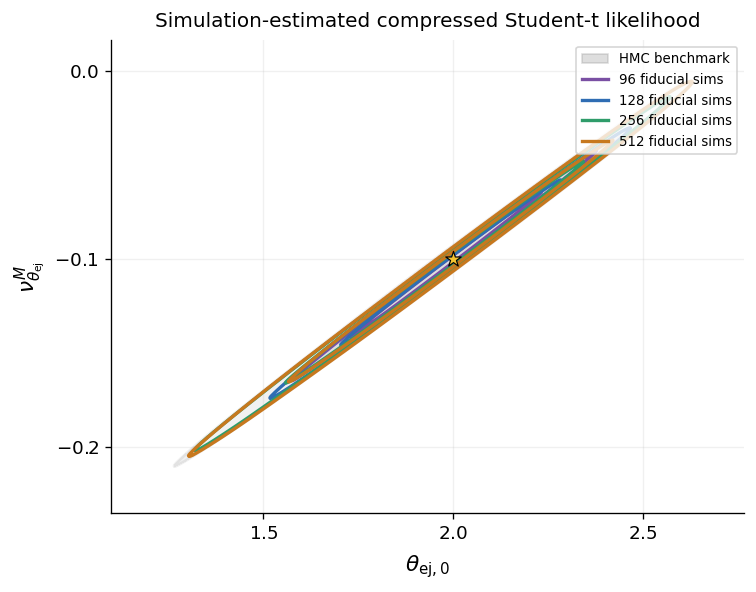

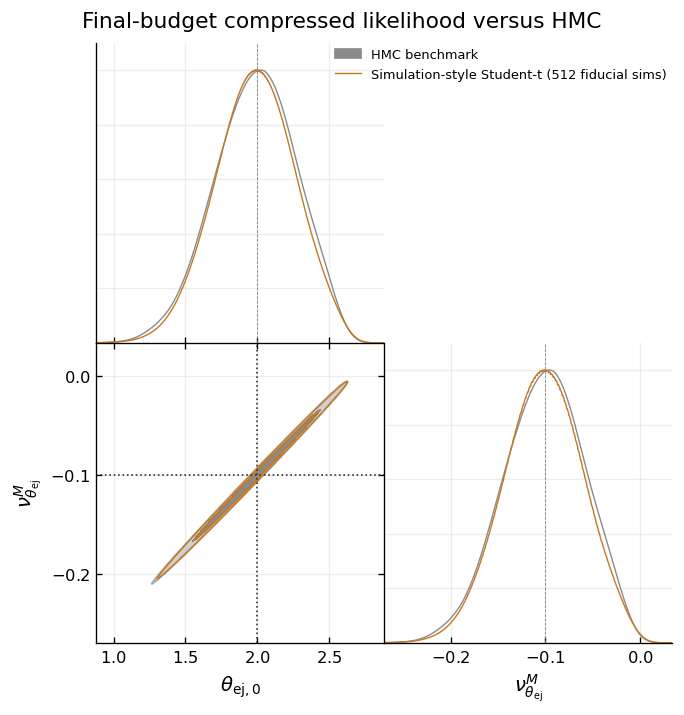

In [10]:
%matplotlib inline
def make_samples(samples: np.ndarray, label: str) -> MCSamples:
    return MCSamples(
        samples=np.asarray(samples, dtype=float),
        names=["thetaej0", "nuejM"],
        labels=[r"\theta_{\rm ej,0}", r"\nu^M_{\theta_{\rm ej}}"],
        label=label,
        settings=GETDIST_SETTINGS,
    )


def style_plotter(g):
    g.settings.axes_fontsize = 11
    g.settings.lab_fontsize = 13
    g.settings.legend_fontsize = 9
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.30
    g.settings.linewidth_contour = 1.5
    return g

budget_colors = {
    96: "#7a4fa3",
    128: "#2f6db3",
    256: "#2f9c6a",
    512: "#c7781e",
}

all_samples = [hmc_samples] + [posterior_results[n]["samples"] for n in sorted(posterior_results)]
stack = np.vstack(all_samples)
qlo, qhi = np.quantile(stack, [0.003, 0.997], axis=0)
span = np.maximum(qhi - qlo, 1.0e-12)
lims = [float(qlo[0] - 0.12 * span[0]), float(qhi[0] + 0.12 * span[0]), float(qlo[1] - 0.12 * span[1]), float(qhi[1] + 0.12 * span[1])]

g = style_plotter(plots.get_single_plotter(width_inch=6.4))
g.plot_2d(
    [make_samples(hmc_samples, "HMC benchmark")],
    "thetaej0",
    "nuejM",
    filled=True,
    colors=["#8a8a8a"],
    alphas=[0.28],
    lws=[1.0],
    lims=lims,
)
ax = plt.gca()
legend_labels = ["HMC benchmark"]
for n_cov in sorted(posterior_results):
    g.plot_2d(
        [make_samples(posterior_results[n_cov]["samples"], f"{n_cov} sims")],
        "thetaej0",
        "nuejM",
        filled=False,
        colors=[budget_colors.get(n_cov, "#333333")],
        lws=[2.0],
        ls=["-"],
        lims=lims,
        ax=ax,
    )
    legend_labels.append(f"{n_cov} fiducial sims")
ax.scatter(THETA0[0], THETA0[1], marker="*", s=95, color="#f4c430", edgecolor="black", linewidth=0.7, zorder=5)
ax.set_title("Simulation-estimated compressed Student-t likelihood", fontsize=12, pad=8)
ax.grid(alpha=0.18)
g.add_legend(legend_labels, legend_loc="upper right", ax=ax, fontsize=8, frameon=False)
plt.show()
plt.close(g.fig)

# A less crowded final-budget view.
final_budget = max(posterior_results)
g = style_plotter(plots.get_subplot_plotter(width_inch=5.8))
g.triangle_plot(
    [make_samples(hmc_samples, "HMC"), make_samples(posterior_results[final_budget]["samples"], f"Student-t {final_budget}")],
    params=["thetaej0", "nuejM"],
    filled=[True, False],
    contour_colors=["#8a8a8a", budget_colors.get(final_budget, "#2f9c6a")],
    legend_labels=["HMC benchmark", f"Simulation-style Student-t ({final_budget} fiducial sims)"],
    markers={"thetaej0": THETA0[0], "nuejM": THETA0[1]},
    marker_args={"color": "#333333", "ls": ":", "lw": 1.0},
)
g.fig.suptitle("Final-budget compressed likelihood versus HMC", y=1.02, fontsize=13)
plt.show()
plt.close(g.fig)

## Scalar Validation Metrics

These diagnostics quantify how quickly the simulation-estimated compressed Student-t posterior approaches the HMC benchmark as the number of fiducial simulations used for covariance estimation increases.

In [9]:
def posterior_metrics(samples: np.ndarray) -> dict[str, float]:
    samples = np.asarray(samples, dtype=float)
    mean = samples.mean(axis=0)
    cov = np.cov(samples.T, ddof=1)
    std = np.sqrt(np.diag(cov))
    delta = mean - hmc_mean
    eig_cov = hmc_evecs.T @ cov @ hmc_evecs
    eig_widths = np.sqrt(np.clip(np.diag(eig_cov), 0.0, np.inf))
    return {
        "mean_shift_hmc_sigma": float(np.sqrt(delta @ hmc_inv_cov @ delta)),
        "theta_width_ratio": float(std[0] / hmc_std[0]),
        "nu_width_ratio": float(std[1] / hmc_std[1]),
        "area_ratio": float(np.sqrt(max(np.linalg.det(cov), 0.0) / max(np.linalg.det(hmc_cov), 1.0e-300))),
        "wide_dir_width_ratio": float(eig_widths[0] / hmc_dir_widths[0]),
        "narrow_dir_width_ratio": float(eig_widths[1] / hmc_dir_widths[1]),
    }

metric_rows = []
for n_cov, result in posterior_results.items():
    row = {"n_cov": int(n_cov)}
    row.update(posterior_metrics(result["samples"]))
    metric_rows.append(row)
metric_rows = sorted(metric_rows, key=lambda row: row["n_cov"])
display_table(metric_rows)

fig, axes = plt.subplots(2, 2, figsize=(11.2, 7.8), sharex=True)
axes = axes.ravel()
metrics = [
    ("mean_shift_hmc_sigma", "mean shift [HMC sigma]"),
    ("area_ratio", "posterior area / HMC"),
    ("wide_dir_width_ratio", "wide-direction width / HMC"),
    ("narrow_dir_width_ratio", "narrow-direction width / HMC"),
]
for ax, (key, ylabel) in zip(axes, metrics):
    x = [row["n_cov"] for row in metric_rows]
    y = [row[key] for row in metric_rows]
    ax.plot(x, y, marker="o", lw=1.8, color="#2f6db3")
    ax.set_xscale("log")
    ax.axhline(1.0, color="0.45", lw=0.9, ls="--")
    if key == "mean_shift_hmc_sigma":
        ax.axhline(0.0, color="0.45", lw=0.9, ls="--")
    ax.set_ylabel(ylabel)
for ax in axes[-2:]:
    ax.set_xlabel("fiducial simulations used for covariance")
fig.suptitle("Convergence of simulation-style compressed Student-t posterior", y=1.02, fontsize=14)
fig.tight_layout()
plt.show()
plt.close(fig)

,n_cov,mean_shift_hmc_sigma,theta_width_ratio,nu_width_ratio,area_ratio,wide_dir_width_ratio,narrow_dir_width_ratio
0,96,0.054946,0.567725,0.575411,0.236939,0.567908,0.434840
1,128,0.360081,0.667917,0.672253,0.445089,0.668013,0.669409
2,256,0.152762,0.894129,0.893785,0.695644,0.894132,0.778013
3,512,0.069475,0.966513,0.967430,0.882475,0.966538,0.913184


## Replacement Checklist for Map Simulations and Higher-Order Statistics

For the next iteration, keep the calibration and likelihood code unchanged and replace only the statistic interface:

- `get_observed_statistic()` should return the measured statistic vector from the observed maps/catalogs.
- `simulate_statistic(theta, seed)` should run one simulation at parameters `theta`, add survey/noise realizations, measure the statistic vector, and return a 1D NumPy array.
- The statistic can be any fixed-length vector: two-point $C_\ell$s, moments, cross-moments, peak counts, or a concatenation.
- The finite-difference calibration assumes the same statistic ordering and length for every simulation.
- If common random numbers are not available for plus/minus simulations, set `USE_COMMON_RANDOM_NUMBERS_FOR_FD = False` and increase `N_FD_PAIRS`.

The HMC comparison and hidden-covariance checks should be removed once no analytical benchmark exists; the simulation-style Student-t likelihood itself does not require them.